In [1]:
!pip install pandas numpy scikit-learn pgmpy networkx matplotlib

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 22.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   --------------------------------------- 756.0/756.0 kB 15.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

import networkx as nx
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("~/Downloads/STARD.csv")

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])
print(data.columns)

Rows: 3679
Columns: 48
Index(['id', 'concat', 'Gender', 'weeks', 'CIT', 'Bupropion', 'Mirzapine',
       'Buspirone', 'Lithium', 'Nortriptyline', 'Sertraline', 'Thyroid',
       'Tranylclypromine', 'Venlafaxine', 'remission', 'RiskOfSuicide',
       'Heart', 'Vascular', 'Haematopoietic', 'Eyes_Ears_Nose_Throat_Larynx',
       'Gastrointestinal', 'Renal', 'Genitourinary',
       'Musculoskeletal_Integument', 'Neurological', 'Psychiatric_Illness',
       'Respiratory', 'Liver', 'Endocrine', 'Alcohol', 'Amphetamine',
       'Cannibis', 'Opioid', 'Panic', 'Specific_Phobia', 'Social_Phobia',
       'OCD', 'PTSD', 'Anxiety', 'Borderline_Personality',
       'Dependent_Personality', 'Antisocial_Personality',
       'Paranoid_Personality', 'Personality_Disorder', 'Anorexia', 'Bulimia',
       'Cocaine', 'Citalopram'],
      dtype='object')


In [6]:
keep_vars = [
"remission","Gender","Citalopram",
"Thyroid","RiskOfSuicide","Heart","Vascular","Haematopoietic",
"Eyes_Ears_Nose_Throat_Larynx","Gastrointestinal","Renal",
"Genitourinary","Musculoskeletal_Integument","Neurological",
"Psychiatric_Illness","Respiratory","Liver","Endocrine",
"Alcohol","Amphetamine","Cannibis","Opioid",
"Panic","Specific_Phobia","Social_Phobia",
"OCD","PTSD","Anxiety","Borderline_Personality",
"Dependent_Personality","Antisocial_Personality",
"Paranoid_Personality","Personality_Disorder",
"Anorexia","Bulimia","Cocaine"
]

data = data[keep_vars]

In [7]:
#clean the data
data = data.replace(["NULL",""], np.nan)
data = data.dropna()

for col in data.columns:
    data[col] = data[col].astype(int)

print("Clean dataset shape:", data.shape)

Clean dataset shape: (3678, 36)


In [8]:
X = data.drop(columns=["remission"])     #predictors/features
y = data["remission"]                    #outcome/target

In [9]:
y.head(5); X.head(5)

,Gender,Citalopram,Thyroid,RiskOfSuicide,Heart,Vascular,Haematopoietic,Eyes_Ears_Nose_Throat_Larynx,Gastrointestinal,Renal,...,PTSD,Anxiety,Borderline_Personality,Dependent_Personality,Antisocial_Personality,Paranoid_Personality,Personality_Disorder,Anorexia,Bulimia,Cocaine
0,0,1,0,0,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
#find the Markov blanket of remission
lasso = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    cv=5,
    scoring="roc_auc",
    max_iter=5000,
    random_state=42
)

lasso.fit(X, y)

LogisticRegressionCV(cv=5, max_iter=5000, penalty='l1', random_state=42,
                     scoring='roc_auc', solver='saga')

In [11]:
#extract selected predictors - parents of remission
coef = pd.Series(lasso.coef_[0], index=X.columns)

selected = coef[coef != 0]

print("Selected predictors of remission:")
print(selected.sort_values(key=abs, ascending=False))

Selected predictors of remission:
RiskOfSuicide                  -0.595773
PTSD                           -0.587254
Anxiety                        -0.367490
OCD                             0.339711
Neurological                   -0.227863
Cannibis                       -0.221214
Liver                          -0.166397
Endocrine                       0.146754
Respiratory                    -0.138371
Alcohol                         0.133001
Eyes_Ears_Nose_Throat_Larynx    0.111630
Vascular                       -0.104631
Musculoskeletal_Integument     -0.070523
Citalopram                      0.061920
Gender                         -0.052363
Heart                          -0.045952
Panic                          -0.017129
Genitourinary                   0.011107
Renal                          -0.010104
dtype: float64


In [12]:
#select top 5 predictors
top5 = selected.reindex(selected.abs().sort_values(ascending=False).index).head(5)
print(top5)

RiskOfSuicide   -0.595773
PTSD            -0.587254
Anxiety         -0.367490
OCD              0.339711
Neurological    -0.227863
dtype: float64


In [15]:
#select predictors above a threshold
important = selected[selected.abs() > 0.15]
print(important)

RiskOfSuicide   -0.595773
Neurological    -0.227863
Liver           -0.166397
Cannibis        -0.221214
OCD              0.339711
PTSD            -0.587254
Anxiety         -0.367490
dtype: float64


In [27]:
#from step1 i.e., the DAG sketched in GeNIe or Netica 
edges = [
("Gender","Thyroid"),
("Gender","Neurological"),
("Gender","PTSD"),

("Neurological","Citalopram"),
("PTSD","Citalopram"),
("Anxiety","Citalopram")
]

In [28]:
#add parents of remission
for parent in selected.index:
    edges.append((parent,"remission"))

In [29]:
#create Bayesian network
model = DiscreteBayesianNetwork(edges)

print("Nodes:", model.nodes())
print("Edges:", model.edges())

Nodes: ['Gender', 'Thyroid', 'Neurological', 'PTSD', 'Citalopram', 'Anxiety', 'remission', 'RiskOfSuicide', 'Heart', 'Vascular', 'Eyes_Ears_Nose_Throat_Larynx', 'Renal', 'Genitourinary', 'Musculoskeletal_Integument', 'Respiratory', 'Liver', 'Endocrine', 'Alcohol', 'Cannibis', 'Panic', 'OCD']
Edges: [('Gender', 'Thyroid'), ('Gender', 'Neurological'), ('Gender', 'PTSD'), ('Gender', 'remission'), ('Neurological', 'Citalopram'), ('Neurological', 'remission'), ('PTSD', 'Citalopram'), ('PTSD', 'remission'), ('Citalopram', 'remission'), ('Anxiety', 'Citalopram'), ('Anxiety', 'remission'), ('RiskOfSuicide', 'remission'), ('Heart', 'remission'), ('Vascular', 'remission'), ('Eyes_Ears_Nose_Throat_Larynx', 'remission'), ('Renal', 'remission'), ('Genitourinary', 'remission'), ('Musculoskeletal_Integument', 'remission'), ('Respiratory', 'remission'), ('Liver', 'remission'), ('Endocrine', 'remission'), ('Alcohol', 'remission'), ('Cannibis', 'remission'), ('Panic', 'remission'), ('OCD', 'remission')]

In [32]:
#learn parameters from data - this is equivalent to Netica learn step
model.fit(data, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'remission': 'N', 'Gender': 'N', 'Citalopram': 'N', 'Thyroid': 'N', 'RiskOfSuicide': 'N', 'Heart': 'N', 'Vascular': 'N', 'Haematopoietic': 'N', 'Eyes_Ears_Nose_Throat_Larynx': 'N', 'Gastrointestinal': 'N', 'Renal': 'N', 'Genitourinary': 'N', 'Musculoskeletal_Integument': 'N', 'Neurological': 'N', 'Psychiatric_Illness': 'N', 'Respiratory': 'N', 'Liver': 'N', 'Endocrine': 'N', 'Alcohol': 'N', 'Amphetamine': 'N', 'Cannibis': 'N', 'Opioid': 'N', 'Panic': 'N', 'Specific_Phobia': 'N', 'Social_Phobia': 'N', 'OCD': 'N', 'PTSD': 'N', 'Anxiety': 'N', 'Borderline_Personality': 'N', 'Dependent_Personality': 'N', 'Antisocial_Personality': 'N', 'Paranoid_Personality': 'N', 'Personality_Disorder': 'N', 'Anorexia': 'N', 'Bulimia': 'N', 'Cocaine': 'N'}


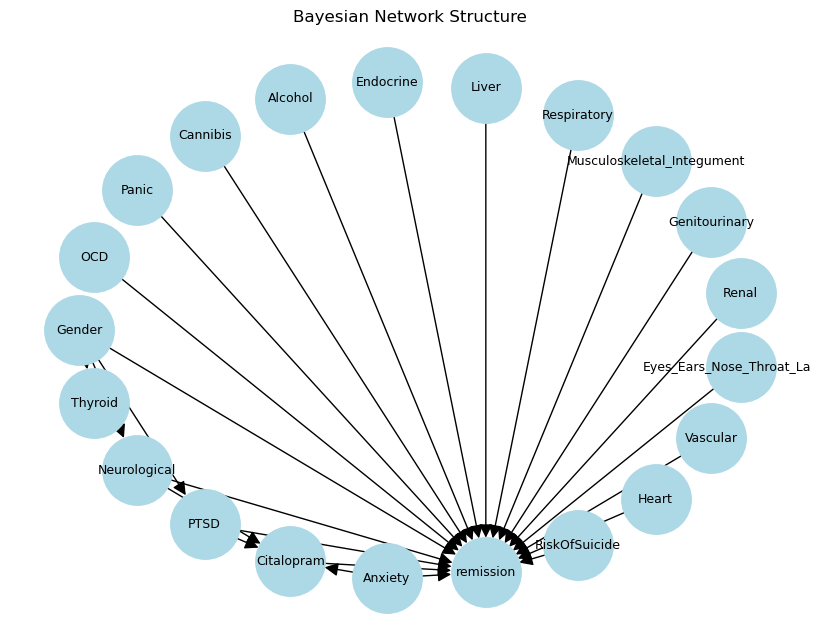

In [34]:
#visualize the network
G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(8,6))
pos = nx.shell_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=2500,
    font_size=9,
    arrowsize=20
)

plt.title("Bayesian Network Structure")
plt.show()

In [35]:
print(sorted(model.edges()))

[('Alcohol', 'remission'), ('Anxiety', 'Citalopram'), ('Anxiety', 'remission'), ('Cannibis', 'remission'), ('Citalopram', 'remission'), ('Endocrine', 'remission'), ('Eyes_Ears_Nose_Throat_Larynx', 'remission'), ('Gender', 'Neurological'), ('Gender', 'PTSD'), ('Gender', 'Thyroid'), ('Gender', 'remission'), ('Genitourinary', 'remission'), ('Heart', 'remission'), ('Liver', 'remission'), ('Musculoskeletal_Integument', 'remission'), ('Neurological', 'Citalopram'), ('Neurological', 'remission'), ('OCD', 'remission'), ('PTSD', 'Citalopram'), ('PTSD', 'remission'), ('Panic', 'remission'), ('Renal', 'remission'), ('Respiratory', 'remission'), ('RiskOfSuicide', 'remission'), ('Vascular', 'remission')]


In [36]:
#inference
infer = VariableElimination(model)

In [37]:
#predict remission probability: neurological disease = 1, PTSD = 1, Citalopram = 1
q = infer.query(
    variables=["remission"],
    evidence={
        "Neurological":1,
        "PTSD":1,
        "Citalopram":1
    }
)

print(q)

+--------------+------------------+
| remission    |   phi(remission) |
+==============+==================+
| remission(0) |           0.5017 |
+--------------+------------------+
| remission(1) |           0.4983 |
+--------------+------------------+


In [38]:
#compare treated vs untreated
treated = infer.query(
    variables=["remission"],
    evidence={"Neurological":1,"PTSD":1,"Citalopram":1}
)

untreated = infer.query(
    variables=["remission"],
    evidence={"Neurological":1,"PTSD":1,"Citalopram":0}
)

print("Remission if treated:")
print(treated)

print("Remission if NOT treated:")
print(untreated)

Remission if treated:
+--------------+------------------+
| remission    |   phi(remission) |
+==============+==================+
| remission(0) |           0.5017 |
+--------------+------------------+
| remission(1) |           0.4983 |
+--------------+------------------+
Remission if NOT treated:
+--------------+------------------+
| remission    |   phi(remission) |
+==============+==================+
| remission(0) |           0.5164 |
+--------------+------------------+
| remission(1) |           0.4836 |
+--------------+------------------+


In [39]:
#Treatment Effect - means treated cohort has X% of higher probability of remission compared to untreated cohort
#In other words, Treatment Effect = P(Remission/Treated) - P(Remission/Untreated)
p_treated = treated.values[1]
p_untreated = untreated.values[1]

effect = p_treated - p_untreated           # 0.4982 - 0.4836  = 0.0146

print("Estimated treatment effect:", effect)

Estimated treatment effect: 0.014655093086271664


In [40]:
print(p_treated, p_untreated)


0.4982556382184037 0.483600545132132
